In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("/content/btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume,datetime
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00+00:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00+00:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00+00:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00+00:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00+00:00


In [8]:
# Drop rows with NaN or Inf values
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [9]:
# Replace NaN or Inf values with the column mean
df['Close'] = df['Close'].replace([np.inf, -np.inf], np.nan)
df['Close'] = df['Close'].fillna(df['Close'].mean())

In [10]:
# Verify that no NaN or Inf values remain
assert not df['Close'].isnull().any(), "NaN values still present!"
assert not np.isinf(df['Close']).any(), "Inf values still present!"

In [11]:
# Normalize the data again after cleaning
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load dataset (skip this if already loaded)
# df = pd.read_csv("your_bitcoin_file.csv")

# 1. Convert 'datetime' to proper datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. Sort by datetime (just to be sure)
df = df.sort_values(by='datetime')

# 3. Drop columns that won't be used (optional)
df = df[['datetime', 'Close']]

# 4. Set datetime as index (optional but good for visualization)
df.set_index('datetime', inplace=True)

# 5. Normalize 'Close' prices
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(df[['Close']])

# 6. Create sequences for LSTM
def create_sequences(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_close, time_step)

# 7. Split into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 8. Reshape X for LSTM [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# ✅ Print shapes for confirmation
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (215428, 60, 1)
y_train shape: (215428, 1)
X_test shape: (53857, 60, 1)
y_test shape: (53857, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0074 - val_loss: 9.6447e-04
Epoch 2/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5.6423e-04 - val_loss: 7.5424e-04
Epoch 3/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - loss: 3.3002e-04 - val_loss: 1.0809e-04
Epoch 4/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 2.3473e-04 - val_loss: 6.0220e-05
Epoch 5/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - loss: 1.8518e-04 - val_loss: 5.0197e-05
Epoch 6/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 1.5968e-04 - val_loss: 2.6763e-05
Epoch 7/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - loss: 1.3704e-04 - val_loss: 2.0153e-05
Epoch 8/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 1.2156e-04 - val_loss: 5.1187e-05
Epoch 9/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - loss: 1.1237e-04 - val_loss: 5.0638e-05
Epoch 10/10
3030/3030 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - loss: 1.0458e-04 - val_loss: 2.8888e-05
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 7

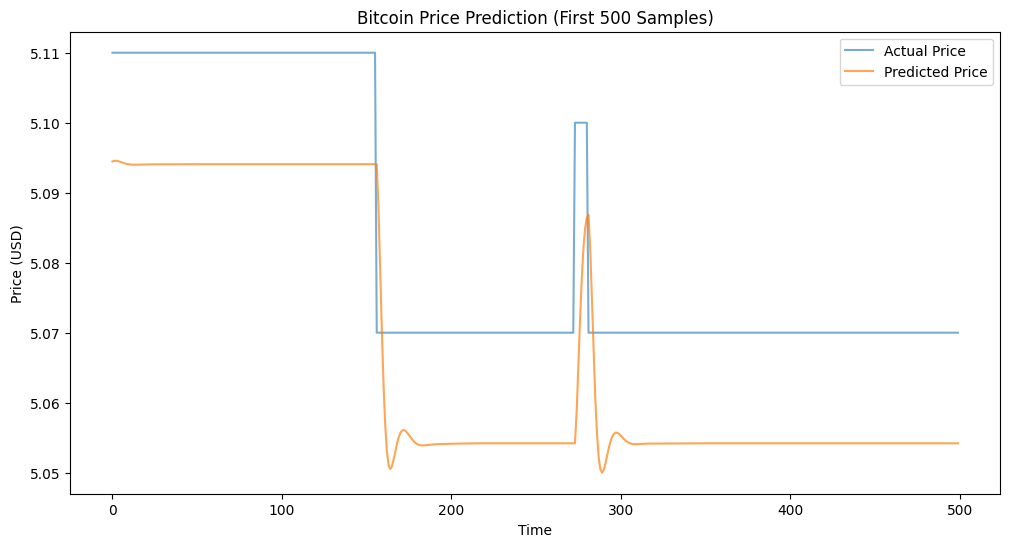

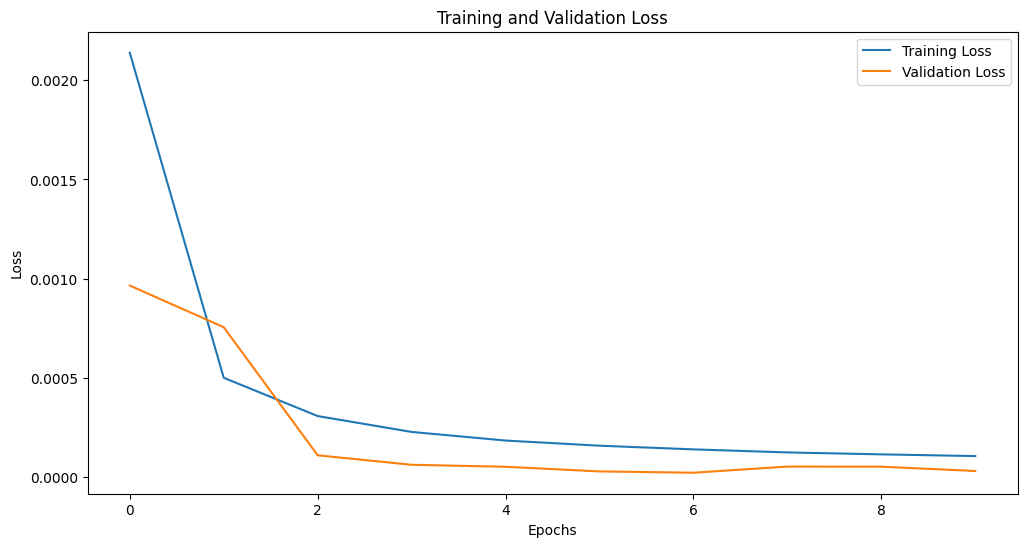

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ---- Data Preprocessing ----
# Assuming 'df' is the DataFrame that contains your data
# Replace NaN or Inf values and fill missing values
df = df.replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN
df['Close'] = df['Close'].fillna(df['Close'].mean())  # Fill NaN with column mean

# Normalize the 'Close' price
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# ---- Create Sequences ----
sequence_length = 60
X, y = [], []
for i in range(sequence_length, len(scaled_close)):
    X.append(scaled_close[i - sequence_length:i])
    y.append(scaled_close[i])
X, y = np.array(X), np.array(y)

# ---- Split Data into Training and Test ----
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# ---- Model Building ----
model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=64),
    Dropout(0.2),
    Dense(units=32, activation='relu'),
    Dense(units=1)
])

# ---- Compile with Optimizer ----
optimizer = Adam(learning_rate=0.0001, clipvalue=1.0)  # Lower learning rate
model.compile(optimizer=optimizer, loss='mean_squared_error')

# ---- Train the Model ----
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

# ---- Evaluate the Model ----
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.6f}")

# ---- Make Predictions ----
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# ---- Plot the Results ----
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:500], label='Actual Price', alpha=0.6)
plt.plot(y_pred_inv[:500], label='Predicted Price', alpha=0.7)
plt.title("Bitcoin Price Prediction (First 500 Samples)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# ---- Plot Training and Validation Loss ----
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming you have your test data (X_test) and predictions (y_pred) from your model
# For example:
# model = RandomForestRegressor()  # or your chosen model
# model.fit(X_train, y_train)  # model training (done earlier)

# Predict the Bitcoin prices on the test set
y_pred = model.predict(X_test)

# Evaluate using MSE, MAE, and R-squared
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R-squared (R²): {r2:.2f}')

1684/1684 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Mean Squared Error (MSE): 0.00
Mean Absolute Error (MAE): 0.04
R-squared (R²): 0.88


In [19]:
# Save the model to a specific directory
model_path = "/content/saved/bitcoin_lstm_model.h5"

# Create directory if it doesn't exist
import os
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save the model
model.save(model_path)
print(f"Model saved to: {model_path}")


Model saved to: /content/saved/bitcoin_lstm_model.h5


In [22]:
import numpy as np

# Define a tolerance threshold (e.g., 5%)
tolerance = 0.05  # 5%

# Flatten arrays if needed
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

# Compute how many predictions are within 5% of the true value
accuracy_like = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv) < tolerance)

print(f"Accuracy (within ±5%): {accuracy_like * 100:.2f}%")

Accuracy (within ±5%): 99.88%


1684/1684 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


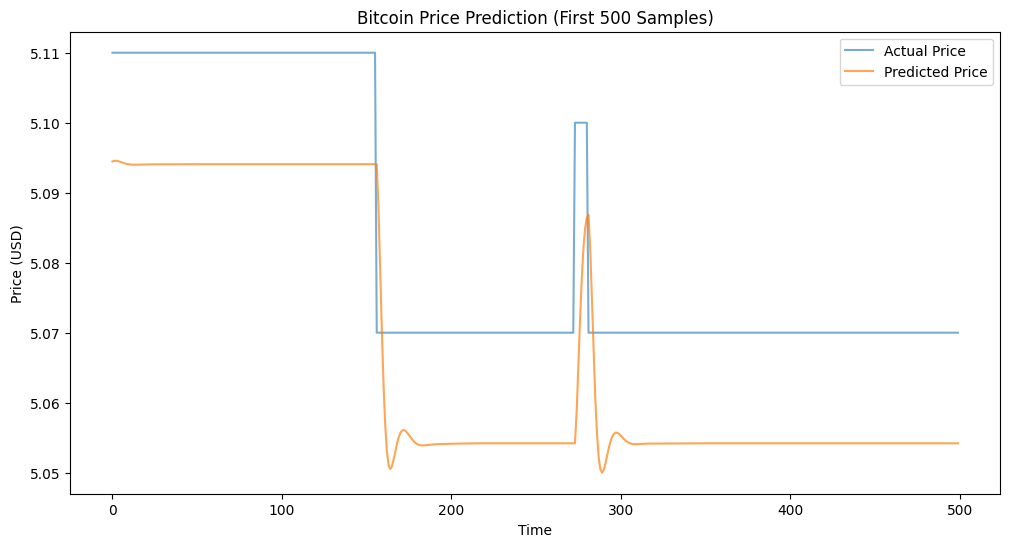

In [23]:
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
model = load_model("/bitcoin_lstm_model.h5")

# Predict again using test data
y_pred = model.predict(X_test)

# Inverse transform to original price scale
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:500], label='Actual Price', alpha=0.6)
plt.plot(y_pred_inv[:500], label='Predicted Price', alpha=0.7)
plt.title("Bitcoin Price Prediction (First 500 Samples)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()
